In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import sys
sys.path.append("../") 
import WRFDomainLib
mpl.rcParams['hatch.linewidth'] = 0.1
mpl.rcParams['patch.edgecolor']='none'
plt.rcParams["font.family"] = "Sans-Serif"

import xarray as xr
# Example usage
cmap = 'PuOr'#inferno_white()


WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)
    

ERROR 1: PROJ: proj_create_from_database: Open of /home/amh001/space_fs7/software_2022/python/py_2024/share/proj failed


In [2]:
import matplotlib
print(matplotlib.__version__)
import matplotlib.colors as mcolors

print([a for a in dir(mcolors) if "Norm" in a])

3.9.1
['AsinhNorm', 'BoundaryNorm', 'CenteredNorm', 'FuncNorm', 'LogNorm', 'NoNorm', 'Normalize', 'PowerNorm', 'SymLogNorm', 'TwoSlopeNorm']


In [3]:
#load data
filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_wind_rcp85_d03.npz'



data = np.load(filepath)
lat= data ['lat']
lon=data['lon']

In [4]:
season_data = {
    "DJF": (data["DJF_delta"], data["DJF_pval"]),
    "MAM": (data["MAM_delta"], data["MAM_pval"]),
    "JJA": (data["JJA_delta"], data["JJA_pval"]),
    "SON": (data["SON_delta"], data["SON_pval"])
}

In [5]:

filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_wind_rcp85_CanRCM4.npz'
data = np.load(filepath)
latRCM4= data ['lat']
lonRCM4=data['lon']
season_data_RCM4 = {
    "DJF": (data["DJF_delta"], data["DJF_pval"]),
    "MAM": (data["MAM_delta"], data["MAM_pval"]),
    "JJA": (data["JJA_delta"], data["JJA_pval"]),
    "SON": (data["SON_delta"], data["SON_pval"])
}

In [6]:

filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_wind_rcp85_CanESM2.npz'
data = np.load(filepath)
latESM2= data ['lat']
lonESM2=data['lon']
season_data_ESM2 = {
    "DJF": (data["DJF_delta"], data["DJF_pval"]),
    "MAM": (data["MAM_delta"], data["MAM_pval"]),
    "JJA": (data["JJA_delta"], data["JJA_pval"]),
    "SON": (data["SON_delta"], data["SON_pval"])
}

In [7]:
path0='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/ensemble_means/NA-CORDEX_ensemble/'
def loadseason(season,path0):
    file0=path0+f'CORDEX_wind_change_rcp85_{season}.nc'
    ds = xr.open_dataset(file0)

    # Replace 'pr_delta' and 'pr_pval' with the actual variable names in the NetCDF
    delta = ds["sfcWind_relanom"].values
    file0=path0+f'CORDEX_wind_change_rcp45_{season}_robustness.nc'
    ds = xr.open_dataset(file0)
    robust= ds["sfcWind_anom_robustness"].values
    file0=path0+f'CORDEX_wind_change_rcp45_{season}_consensus.nc'
    ds = xr.open_dataset(file0)
    cons = ds["sfcWind_anom_consensus"].values
    #masked_grid = robust 
    masked_grid=(cons < 0.8) & (robust < 0.66) #mask is true where not sig
    lat = ds["lat"].values
    lon=ds['lon'].values
    return delta, masked_grid, lat, lon
seasons= ["DJF", "MAM", "JJA", "SON"];
season_data_CORDEX = {}

for season in seasons:
    delta, mask,latCORD, lonCORD=loadseason(season,path0)
    season_data_CORDEX[season] = (delta, mask)

DJF
pvals 0.9999944741575832 9.029130109311086e-06
pvals 0.9999946301983109 7.722272891101818e-07
pvals 0.9999996197931866 2.401262283969623e-10
pvals 0.9999771337694161 0.0001869270737251311
DJF
DJF RCM4 pvals nan nan
RCM4 field 19.41156 -15.069877
MAM RCM4 pvals nan nan
RCM4 field 15.799497 -19.08163
JJA RCM4 pvals nan nan
RCM4 field 34.767704 -14.25027
SON RCM4 pvals nan nan
RCM4 field 24.106636 -15.346326
DJF
ESM2 pvals 0.9990553558247328 6.444376933584965e-07
ESM2 pvals 0.9993345367925702 1.8092644972504337e-07
ESM2 pvals 0.9995347151773712 8.56190459259477e-07
ESM2 pvals 0.9990762327265219 9.561582918262212e-07
DJF


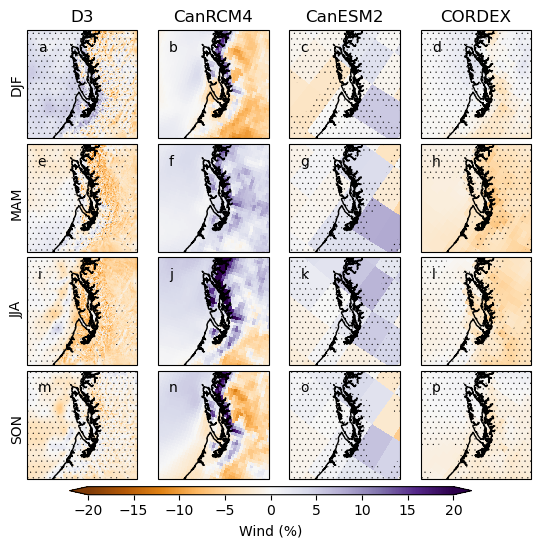

In [8]:
nrows = len(seasons)
ncols = 4
nmodels=ncols
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

at=0.1;bt=0.9

vmin=-20;vmax=20

seasons = ["DJF", "MAM", "JJA", "SON"]
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=ncols,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
j=0
count=0
for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if count==0:
        ax.set_title('D3')
        print(season)
    field = season_data[season][0]
    pval  = season_data[season][1]
    print('pvals', np.amax(pval), np.amin(pval))
    # Main colormap
    mesh = ax.pcolormesh(
        lon, lat, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    #masked_grid = np.ma.masked_where(pval >= 0.1, pval)
    ax.contourf(
        lon, lat,pval,
        levels=[0.1, 1], colors="none", hatches=["..."],
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
    ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
    
    count+=1
##################CanRCM4  ##########3


j=1

for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if season=='DJF':
        ax.set_title('CanRCM4')
        print(season)
    field = season_data_RCM4[season][0]
    pval  = season_data_RCM4[season][1]
    print(season, 'RCM4 pvals', np.amax(pval), np.amin(pval))
    print('RCM4 field', np.amax(field), np.amin(field))

    # Main colormap
    mesh = ax.pcolormesh(
        lonRCM4, latRCM4, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    #masked_grid = np.ma.masked_where(pval >= 0.1, pval)
    ax.contourf(
        lonRCM4, latRCM4, pval,
        levels=[0.1,1], colors="none", hatches=["..."],
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
   # ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

    count+=1
######CANESM2



j=2

for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if season=='DJF':
        ax.set_title('CanESM2')
        print(season)
    field = season_data_ESM2[season][0]
    pval  = season_data_ESM2[season][1]
    print('ESM2 pvals', np.amax(pval), np.amin(pval))

    # Main colormap
    mesh = ax.pcolormesh(
        lonESM2, latESM2, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    #masked_grid = np.ma.masked_where(pval >= 0.1, pval)
    ax.contourf(
        lonESM2, latESM2, pval,
        levels=[0.1, 1], colors="none", hatches=["..."],
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
   # ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

    count+=1



j=3

for i, season in enumerate(seasons):

    ax = axes[i, j] if nmodels > 1 else axes[i]
    if season=='DJF':
        ax.set_title('CORDEX')
        print(season)
    field = season_data_CORDEX[season][0]
    mask  = season_data_CORDEX[season][1]

    # Main colormap
    mesh = ax.pcolormesh(
        lonCORD, latCORD, field,
        cmap=cmap, vmin=vmin,vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    #meshes.append(mesh)

    # Hatching where pval < 0.1
    ax.contourf(
        lonCORD, latCORD, ~mask,
        levels=[0, 0.9], colors="none", hatches=["..."],
        transform=ccrs.PlateCarree()
    )
  #  ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

#    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    # Coastlines
    ax.coastlines()
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    
   # ax.text(-0.15, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())

    count+=1


fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

# One shared colorbar
cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.015])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
cbar.set_label(r"Wind (%)")
plt.savefig('../Figures/wind_RCP85_means.png', format='png', bbox_inches='tight',transparent=False,dpi=500)

In [9]:
#import seaborn as sns


In [10]:



#mpl.rcParams['hatch.color'] = 'gray'
def plotseasons(j, count, season_data, axes, seasons, nmodels, var, lon, lat, label0):
#j=0
#count=0

    #print(vmin, vmax)
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        pval  = season_data[season][1]
        #print('D3 pvals', np.amax(pval), np.amin(pval))
        # Main colormap
        #print(vmin, vmax)
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=cmap, vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        #meshes.append(mesh)
    
        
        cs = ax.contourf(
            lon, lat, pval,
            levels=[0.1, 1],
            colors="none", 
            hatches=hatches,  # pass as a list
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')

    
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        if season=='DJF':
            ax.set_title(label0)
        count+=1


    return count




#mpl.rcParams['hatch.color'] = 'gray'
def plotseasons_ens(j, count, season_data, axes, seasons, nmodels, var, lon, lat,label0):
#j=0
#count=0

    #print(vmin, vmax)
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        mask  = season_data[season][1]
        #print('D3 pvals', np.amax(pval), np.amin(pval))
        # Main colormap
        #print(vmin, vmax)
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=cmap, vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        #meshes.append(mesh)
    
        #~msk is true where sig
        cs = ax.contourf(
            lon, lat, ~mask,
            levels=[0, 0.9],
            colors="none", 
            hatches=hatches,  # pass as a list
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')

    
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        if season=='DJF':
            ax.set_title(label0)
        count+=1


    return count

4


/tmp/amh001/1092/ipykernel_2224/1982878200.py:40: UserWarning: Adding colorbar to a different Figure <Figure size 670x540 with 17 Axes> than <Figure size 670x540 with 17 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")


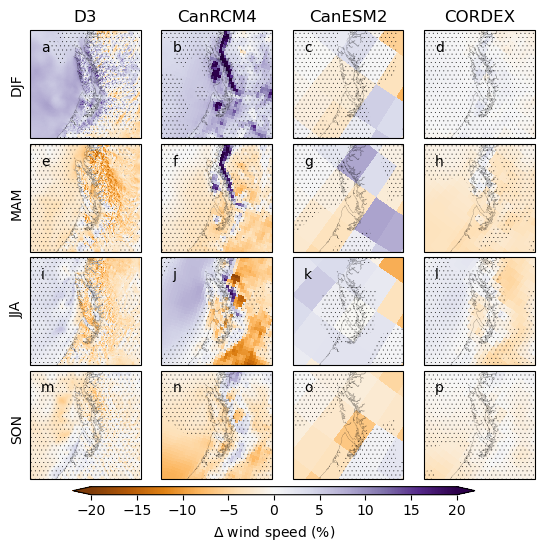

In [11]:
nrows = len(seasons)
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

at=0.1;bt=0.9
#cmap='RdBu_r'

#hatches = ["....."]
# Hatching where pval < 0.1
dense_dots = "." * 2  # repeat the dot
hatches = [dense_dots + " " + dense_dots]  # optional spacing
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(
        nrows=len(seasons), ncols=ncols,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
j=0
count=0



count=plotseasons(j, count, season_data, axes, seasons, nmodels, 't2', lon, lat, 'D3')
print(count)
j=1
count= plotseasons(j, count, season_data_RCM4, axes, seasons, nmodels, 't2', lonRCM4, latRCM4, 'CanRCM4')
j=2
count = plotseasons(j, count, season_data_ESM2, axes, seasons, nmodels, 't2', lonESM2, latESM2, 'CanESM2')
j=3
#The CORDEX and CMIP5 use a mak instead of P-values. it's true where not significant, so we can mask out those areas[0,0.9]
count = plotseasons_ens(j, count, season_data_CORDEX, axes, seasons, nmodels, 't2', lonCORD, latCORD, 'CORDEX')

fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

# One shared colorbar
cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.015])
cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
cbar.set_label(r"$\Delta$ wind speed (%)")


plt.savefig('Figures/wind_RCP45_means.png', format='png', bbox_inches='tight',transparent=False,dpi=500)